# Exp 20 — Plain CLIP Zero-Shot: Octopus Presence

No training. Use CLIP text-image similarity directly to classify frames as **visible** vs **hidden**.

Compare against exp17 (linear probe, 88.8%) and exp18 (MLP, 98.1%) to see how much training helps.

In [1]:
import pkg_resources, packaging
pkg_resources.packaging = packaging

import clip
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
)

PROJECT    = Path(".").resolve().parent
MANIFEST   = PROJECT / "data" / "frames" / "manifest.csv"
CACHE_PATH = PROJECT / "data" / "frames" / "clip_features.npz"

device = (
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available()         else
    "cpu"
)
print(f"Device: {device}")

/var/folders/4x/8gdbr2c547b7s8k94zw4rwmh0000gn/T/ipykernel_68216/4268265639.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources, packaging


Device: mps


## 1 — Load CLIP + cached image features

In [2]:
clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()
print("CLIP ViT-B/32 loaded")

# Load pre-computed normalised image features (reuse from exp17/18)
cache = np.load(CACHE_PATH)
img_features = torch.from_numpy(cache["features"]).to(device)  # (N, 512), already L2-normalised
cached_paths = [str(Path(p).relative_to(PROJECT)) for p in cache["paths"]]
print(f"Loaded {len(img_features)} cached image features")

CLIP ViT-B/32 loaded
Loaded 8658 cached image features


## 2 — Load manifest and align to cache

In [3]:
df = pd.read_csv(MANIFEST)
df["abs_path"] = df["path"].apply(lambda p: PROJECT / p)
df = df[df["abs_path"].apply(lambda p: p.exists())].reset_index(drop=True)
df["y"] = df["label"].map({"visible": 1, "hidden": 0})

path_to_idx = {p: i for i, p in enumerate(cached_paths)}
keep_idx, feat_idx = [], []
for i, row in df.iterrows():
    if row["path"] in path_to_idx:
        keep_idx.append(i)
        feat_idx.append(path_to_idx[row["path"]])

df = df.loc[keep_idx].reset_index(drop=True)
img_feats = img_features[feat_idx]  # aligned to manifest order

print(f"{len(df)} frames aligned")
print(df["label"].value_counts().to_string())

8658 frames aligned
label
hidden     4882
visible    3776


## 3 — Define text prompts

We'll test several prompt variants and pick the best one.

In [4]:
prompt_pairs = [
    (
        "a photo of an octopus in an aquarium tank",
        "a photo of an empty aquarium tank with no animals",
    ),
    (
        "an octopus is visible in the aquarium",
        "no octopus is visible, empty aquarium tank",
    ),
    (
        "octopus present, arms extended, aquarium security camera",
        "octopus absent, empty tank, aquarium security camera",
    ),
    (
        "an octopus with tentacles visible in water",
        "empty aquarium with rocks and sand, no octopus",
    ),
]

print(f"{len(prompt_pairs)} prompt pairs to evaluate")

4 prompt pairs to evaluate


## 4 — Zero-shot classification for each prompt pair

In [5]:
results = []

for pos_prompt, neg_prompt in prompt_pairs:
    # Encode text prompts
    with torch.no_grad():
        tokens = clip.tokenize([neg_prompt, pos_prompt]).to(device)  # [hidden, visible]
        text_feats = clip_model.encode_text(tokens).float()
        text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)

    # Cosine similarity: img_feats @ text_feats.T → (N, 2)
    with torch.no_grad():
        logits = (img_feats @ text_feats.T) * 100  # scale like CLIP does
        probs  = logits.softmax(dim=-1).cpu().numpy()
        preds  = probs.argmax(axis=1)  # 0=hidden, 1=visible

    acc = accuracy_score(df["y"], preds)
    results.append({
        "pos_prompt": pos_prompt,
        "neg_prompt": neg_prompt,
        "accuracy":   acc,
        "preds":      preds,
        "probs":      probs[:, 1],
    })
    print(f"{acc:.1%}  |  '{pos_prompt[:50]}...'")

best = max(results, key=lambda r: r["accuracy"])
print(f"\nBest: {best['accuracy']:.1%}")

43.6%  |  'a photo of an octopus in an aquarium tank...'
44.4%  |  'an octopus is visible in the aquarium...'
55.7%  |  'octopus present, arms extended, aquarium security ...'
52.9%  |  'an octopus with tentacles visible in water...'

Best: 55.7%


## 5 — Detailed report on best prompt

In [6]:
print(f"Best prompt pair:")
print(f"  visible → '{best['pos_prompt']}'")
print(f"  hidden  → '{best['neg_prompt']}'")
print(f"\nTest accuracy: {best['accuracy']:.1%}\n")
print(classification_report(df["y"], best["preds"], target_names=["hidden", "visible"]))

try:
    auc = roc_auc_score(df["y"], best["probs"])
    print(f"ROC-AUC: {auc:.4f}")
except Exception:
    pass

Best prompt pair:
  visible → 'octopus present, arms extended, aquarium security camera'
  hidden  → 'octopus absent, empty tank, aquarium security camera'

Test accuracy: 55.7%

              precision    recall  f1-score   support

      hidden       0.58      0.81      0.67      4882
     visible       0.48      0.23      0.32      3776

    accuracy                           0.56      8658
   macro avg       0.53      0.52      0.49      8658
weighted avg       0.54      0.56      0.52      8658

ROC-AUC: 0.4899


## 6 — Confusion matrix

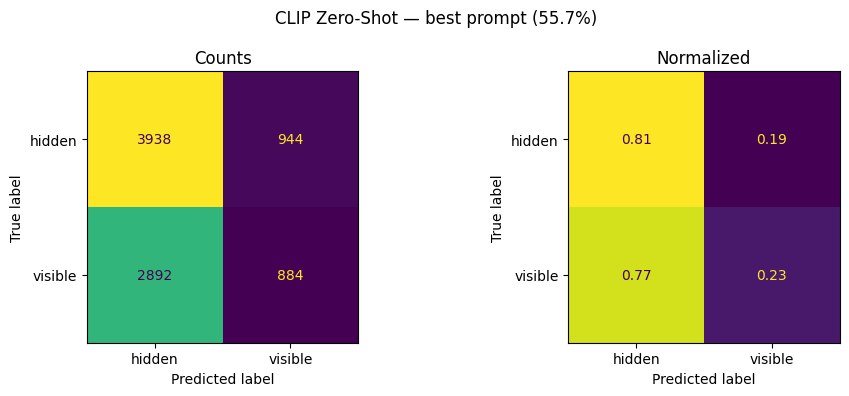

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, normalize, title in zip(axes, [None, "true"], ["Counts", "Normalized"]):
    cm = confusion_matrix(df["y"], best["preds"], normalize=normalize)
    ConfusionMatrixDisplay(cm, display_labels=["hidden", "visible"]).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.suptitle(f"CLIP Zero-Shot — best prompt ({best['accuracy']:.1%})")
plt.tight_layout()
plt.show()

## 7 — Compare all approaches

                        Model  Accuracy
 CLIP zero-shot (best prompt)  0.556942
  CLIP + Linear probe (exp17)  0.888000
CLIP + MLP 512→256→64 (exp18)  0.981000


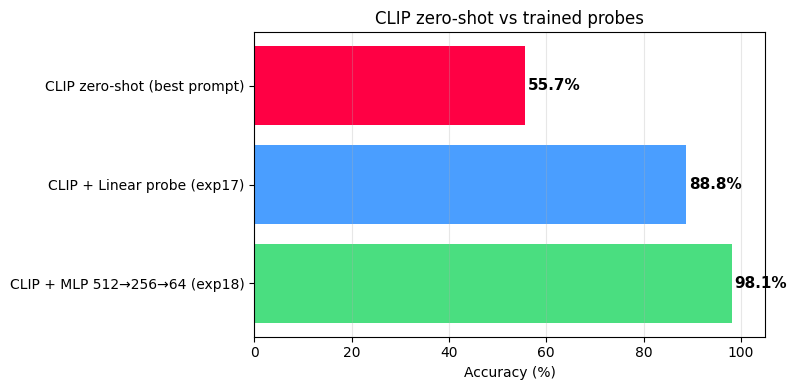

In [8]:
comparison = pd.DataFrame([
    {"Model": "CLIP zero-shot (best prompt)",   "Accuracy": best["accuracy"]},
    {"Model": "CLIP + Linear probe (exp17)",     "Accuracy": 0.888},
    {"Model": "CLIP + MLP 512→256→64 (exp18)",  "Accuracy": 0.981},
])

print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#f04", "#4a9eff", "#4ade80"]
bars = ax.barh(comparison["Model"], comparison["Accuracy"] * 100, color=colors)
ax.set_xlabel("Accuracy (%)")
ax.set_xlim(0, 105)
ax.set_title("CLIP zero-shot vs trained probes")
for bar, acc in zip(bars, comparison["Accuracy"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{acc:.1%}", va="center", fontsize=11, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(PROJECT / "data" / "frames" / "model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()